# Plot distance vs dt for hammer strikes

## Load modules

In [89]:
import numpy as np
import pandas as pd
import math

import glob
import os
import re

import matplotlib.pylab as plt
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec

from obspy import read, UTCDateTime

from scipy.fftpack import fft, fftfreq, next_fast_len

%load_ext autoreload
%autoreload 2
%matplotlib inline 
%matplotlib widget

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [90]:
def calculate_distance(point1, point2):
    # Unpack points
    x1, y1 = point1
    x2, y2 = point2
    
    # Calculate the distance
    distance = math.sqrt((x2 - x1)**2 + (y2 - y1)**2)
    
    return distance

# Function to calculate Euclidean distance from point (px, py) to (x, y)
def calculate_distance_df(row, px, py):
    return np.sqrt((row['lon'] - px) ** 2 + (row['lat'] - py) ** 2)


def plot_spectrum(tr):
    """Plot spectrum of ObsPy trace"""
    tr.detrend('demean')
    #tr.taper(0.5, 'hann')   
    sr = tr.stats.sampling_rate
    nfft = next_fast_len(tr.stats.npts)  # pad data with zeros for fast FT
    pos_freq = (nfft + 1) // 2  # index for positive frequencies
    spec = fft(tr.data, nfft)[:pos_freq]
    freq = fftfreq(nfft, 1 / sr)[:pos_freq]  # get freqs of DFT bin
    return freq, spec 

def extract_digits_from_substring(s, pattern):
    # Use regular expression to find the pattern
    match = re.search(pattern, s)
    
    if match:
        # Extract the digits from the matched pattern
        digits = re.findall(r'\d+', match.group())
        return int(digits[0]) if digits else None
    return None

def determine_orientation(row):
    if len(set(row[['ev_lat', 'lat']])) == 1:
        return 'Horizontal'
    elif len(set(row[['ev_lon', 'lon']])) == 1:
        return 'Vertical'
    else:
        return 'None'
    

## Load files for one hammer strike

#### Your paths and input here

In [91]:
# give the absolute paths to the folders where the data is stored and the picks file
path_to_strikewise_folder = "strike_wise"
number_hammer_strike = 8
phase = 'S'
#picks_file_name = "../HS39_all_tnm_new.txt"
picks_file_name = "PICKS_LAST_YEAR/HS08.txt"

In [92]:
# for saving some outputs
save_path = glob.glob(os.path.dirname(picks_file_name))[0]
# or give your own path to save the outputs; make sure the output path exists
# save_path = "outputs"

#### Loading data into one pandas dataframe

In [93]:
# Load picks 
path_to_picks = picks_file_name
# Load station info
station_info = glob.glob(os.path.join(path_to_strikewise_folder, f"HS{number_hammer_strike:02d}_*/station_info_HS{number_hammer_strike:02d}.txt"))[0]
sta_locs = pd.read_csv(station_info, header=None, comment="#", sep='\s+', names=['sta', 'lat', 'lon', 'elev', 'depth'])
sta_locs['sta'] = sta_locs['sta'].str.replace(r'^SH\.|.$', '', regex=True)

# Load 'event' info 
event_info = glob.glob(os.path.join(path_to_strikewise_folder, f"HS{number_hammer_strike:02d}_*/event_info_HS{number_hammer_strike:02d}.txt"))[0]
event = {}
file1 = open(event_info, 'r')
Lines = file1.readlines()
for line in Lines:
    if "longitude" in line.strip():
        event['longitude'] = float(line.strip().split('=')[1])
    elif "latitude" in line.strip():
        event['latitude'] = float(line.strip().split('=')[1])
    else:
        pass

# put everything together into a pandas data frame 
collect_picks = []

file1 = open(path_to_picks, 'r')
Lines = file1.readlines()
count = 0

session = 1
# experiment = file.split('/')[-2].split('_')[0]
experiment = f"HS{number_hammer_strike:02d}"

# Strips the newline character
for line in Lines:
    count += 1
    if "phase" in line.strip():
        strip_line = line.strip().split()
        try:
            net, sta, loc, cha = strip_line[4].split('.')
        except Exception as exp:
            print(exp)
        if strip_line[8] != phase:
            continue
        
        collect_picks.append([UTCDateTime(f"{strip_line[1]}T{strip_line[2]}"), session, experiment, net, sta, strip_line[8], event['latitude'], event['longitude']])

df_picks = pd.DataFrame(collect_picks, columns = ['datetime',  'session', 'experiment', 'net', 'sta', 'phase', 'ev_lat', 'ev_lon']) 


# df_picks = pd.DataFrame(collect_picks, columns = ['datetime',  'session', 'experiment', 'net', 'sta', 'phase'])

# Merge the two DataFrames based on the 'sta' column
df_picks = pd.merge(df_picks, sta_locs, on='sta', how='left')

# Apply the function to each row and save the result in a new column
df_picks['distance_to_source'] = df_picks.apply(calculate_distance_df, axis=1, px=event['longitude'], py=event['latitude'])

df_picks['orientation'] = df_picks.apply(determine_orientation, axis=1)

print("Number of all picks collected:", len(df_picks))
print("Number of unique experiments:", len(df_picks['experiment'].unique()))
print("\tUnique experiments:", df_picks['experiment'].unique())
print("Number of unique stations:", len(df_picks['sta'].unique()))
df_picks.head()
df_picks.head()


not enough values to unpack (expected 4, got 2)
Number of all picks collected: 30
Number of unique experiments: 1
	Unique experiments: ['HS08']
Number of unique stations: 6


,datetime,session,experiment,net,sta,phase,ev_lat,ev_lon,lat,lon,elev,depth,distance_to_source,orientation
0,2024-06-06T17:37:17.555910Z,1,HS08,SH,39175,S,2.0,-4.0,2.0,-3.0,0,0,1.0,Horizontal
1,2024-06-06T17:37:17.560320Z,1,HS08,SH,33345,S,2.0,-4.0,2.0,-2.0,0,0,2.0,Horizontal
2,2024-06-06T17:37:17.562800Z,1,HS08,SH,31500,S,2.0,-4.0,2.0,-1.0,0,0,3.0,Horizontal
3,2024-06-06T17:37:17.567480Z,1,HS08,SH,33116,S,2.0,-4.0,2.0,0.0,0,0,4.0,Horizontal
4,2024-06-06T17:37:17.571340Z,1,HS08,SH,31786,S,2.0,-4.0,2.0,1.0,0,0,5.0,Horizontal


### Plot what you you loaded

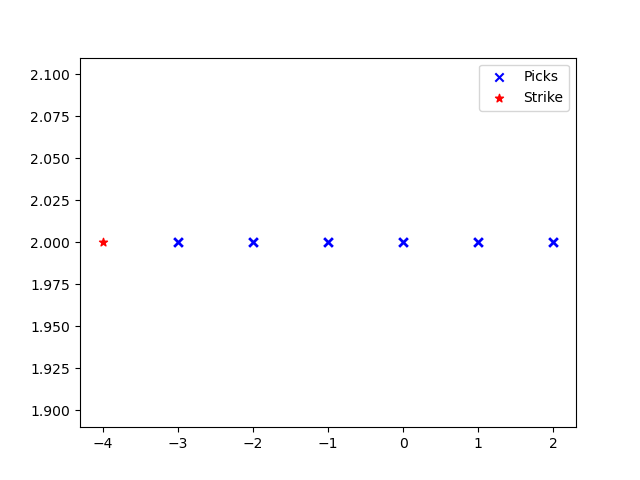

In [94]:
plt.figure()
plt.scatter(df_picks['lon'], df_picks['lat'], c='b', marker='x', label='Picks')
plt.scatter(event['longitude'], event['latitude'], c='r', marker='*', label='Strike')
plt.legend()
plt.show()

## Distance vs Time plot with error bars

In [95]:
first_station = df_picks['distance_to_source'].min()
all_distances = df_picks['distance_to_source'].unique()
all_distances.sort()

In [96]:
df_picks['dt'] = None
df_picks['group'] = None
# Identify the rows where x is 0
min_time = df_picks[df_picks['distance_to_source'] == first_station]['datetime'].values

# Subtract these datetime values from the datetime values of rows where x is greater than 0
for j, times in enumerate(min_time):
    for i, row in df_picks.iterrows():
        if abs(row['datetime'] - min_time[j]) < 0.1: # a bit rough XXX 
            df_picks.at[i, 'dt'] = row['datetime'] - min_time[j]
            df_picks.at[i, 'group'] = j
            # print(i, j, times, row['datetime'], row['dt'])

df_picks.head()

,datetime,session,experiment,net,sta,phase,ev_lat,ev_lon,lat,lon,elev,depth,distance_to_source,orientation,dt,group
0,2024-06-06T17:37:17.555910Z,1,HS08,SH,39175,S,2.0,-4.0,2.0,-3.0,0,0,1.0,Horizontal,0.0,0
1,2024-06-06T17:37:17.560320Z,1,HS08,SH,33345,S,2.0,-4.0,2.0,-2.0,0,0,2.0,Horizontal,0.00441,0
2,2024-06-06T17:37:17.562800Z,1,HS08,SH,31500,S,2.0,-4.0,2.0,-1.0,0,0,3.0,Horizontal,0.00689,0
3,2024-06-06T17:37:17.567480Z,1,HS08,SH,33116,S,2.0,-4.0,2.0,0.0,0,0,4.0,Horizontal,0.01157,0
4,2024-06-06T17:37:17.571340Z,1,HS08,SH,31786,S,2.0,-4.0,2.0,1.0,0,0,5.0,Horizontal,0.01543,0


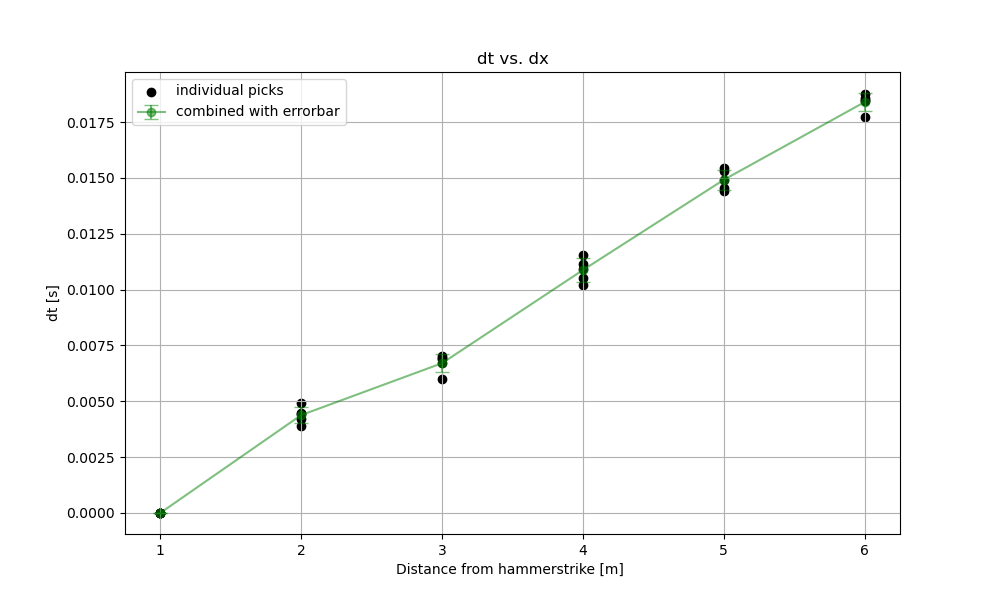

In [97]:
grouped = df_picks.groupby('distance_to_source')['dt'].agg(['mean', 'std']).reset_index()

plt.figure(figsize=(10, 6))
plt.scatter(df_picks['distance_to_source'], df_picks['dt'], color='k', marker='o', linestyle='-', label='individual picks')

plt.errorbar(grouped['distance_to_source'], grouped['mean'], yerr=grouped['std'], color='g', fmt='o', linestyle='-', capsize=5, alpha=0.5, label='combined with errorbar')

plt.xlabel('Distance from hammerstrike [m] ')
plt.ylabel('dt [s]')
plt.title('dt vs. dx')
plt.legend()
# plt.gca().invert_yaxis()  # Optional: Invert y-axis if needed
plt.grid(True)
plt.show()

# Export with x, y, dist, mean, and std
grouped_extended = pd.merge(grouped, df_picks[['distance_to_source', 'lon', 'lat', 'ev_lat', 'ev_lon' , 'phase', 'orientation', 'sta', 'experiment']].drop_duplicates(), on='distance_to_source', how='left')
grouped_extended.to_csv(os.path.join(save_path, f"grouped_mean_std_HS{number_hammer_strike:02d}.csv"))

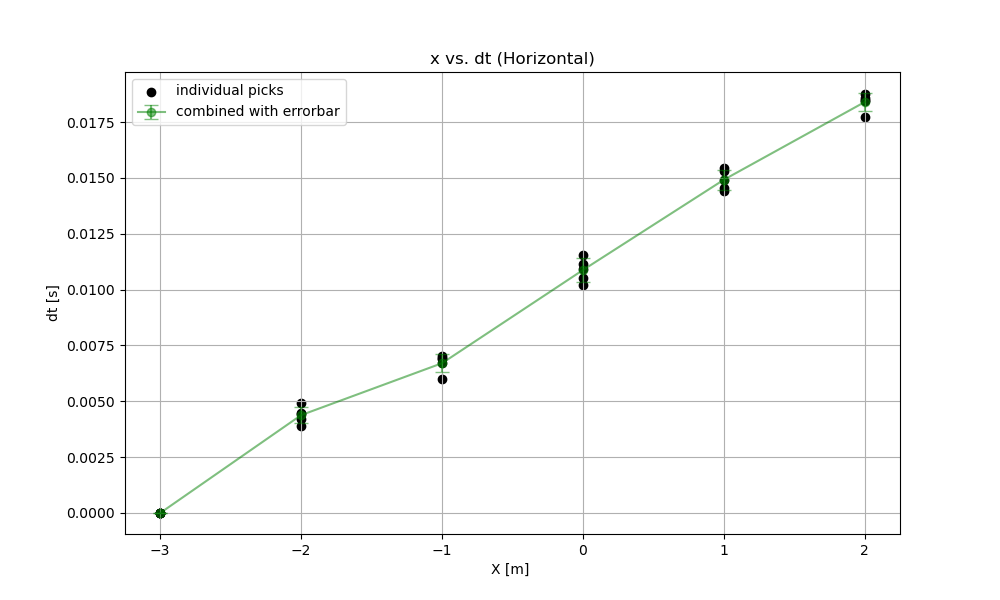

In [98]:
# extra plot with absolute distance instead of relative distance

plt.figure(figsize=(10, 6))

if df_picks.orientation.unique()[0] == 'Horizontal':
    grouped = df_picks.groupby('lon')['dt'].agg(['mean', 'std']).reset_index()

    plt.scatter(df_picks['lon'], df_picks['dt'], color='k', marker='o', linestyle='-', label='individual picks')
    plt.errorbar(grouped['lon'], grouped['mean'], yerr=grouped['std'], color='g', fmt='o', linestyle='-', capsize=5, alpha=0.5, label='combined with errorbar')
    plt.xlabel('X [m] ')
    plt.ylabel('dt [s]')
    plt.title('x vs. dt (Horizontal)')

if df_picks.orientation.unique()[0] == 'Vertical':
    grouped = df_picks.groupby('lat')['dt'].agg(['mean', 'std']).reset_index()

    plt.scatter(df_picks['dt'], df_picks['lat'], color='k', marker='o', linestyle='-', label='individual picks')
    plt.errorbar(grouped['mean'], grouped['lat'], xerr=grouped['std'], color='g', fmt='o', linestyle='-', capsize=5, alpha=0.5, label='combined with errorbar')
    plt.ylabel('Y [m] ')
    plt.xlabel('dt [s]')
    plt.title('dt vs. y (Vertical)')

plt.legend()
plt.grid(True)
plt.show()



## Plot waveforms based on picks (not normalised)

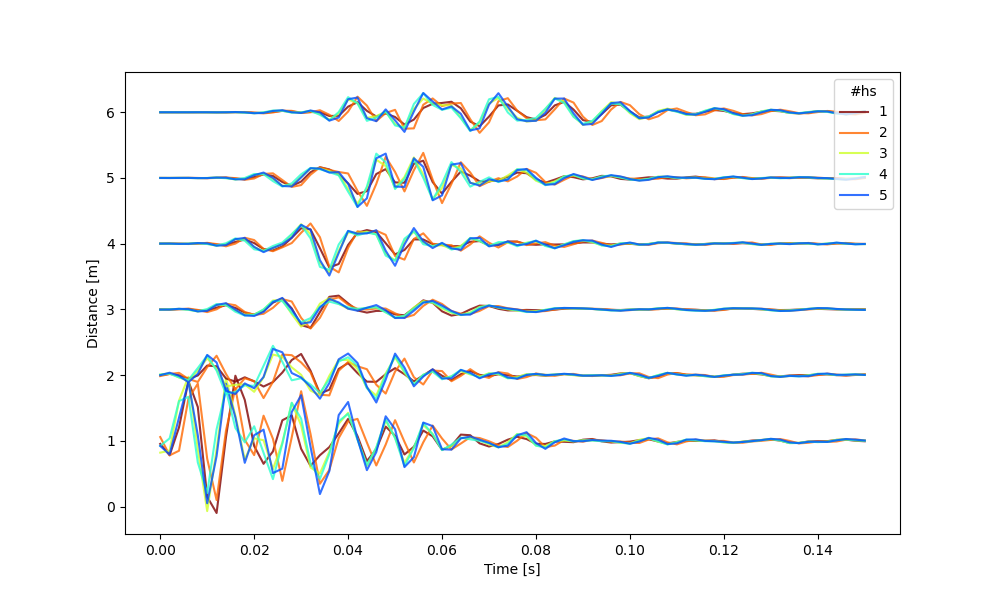

In [99]:
from matplotlib.colors import ListedColormap
plt.figure(figsize=(10, 6))

# Ensure 'group' column contains only numeric values and handle NaNs
df_picks['group'] = pd.to_numeric(df_picks['group'], errors='coerce')

# Create a colormap
cmap = plt.get_cmap('jet_r')  # 'tab10' has 10 distinct colors
norm = mcolors.Normalize(vmin=0, vmax=len(df_picks['group'].unique()))

# Dictionary to store legend handles
legend_handles = {}

for j, station in enumerate(df_picks['sta'].unique()):
    st = read(glob.glob(os.path.join(path_to_strikewise_folder, f"HS{number_hammer_strike:02d}_*/*{station}*.mseed"))[0])
    # XXX filter 2-150 Hz XXX 2-50/70 XXX 70-150 XXX 

    # broadband: frequency vs distance 
    selected_sta = df_picks[df_picks['sta'] == station].sort_values('datetime')

    for i, row in selected_sta.iterrows():

        st_sliced = st.copy()
        st_sliced.trim(row['datetime']-row['dt'], row['datetime']+0.15-row['dt'])
        
        time_axis = st_sliced[0].times()
        
        group_index = np.where(df_picks['group'].unique() == row['group'])[0][0]
        line, = plt.plot(time_axis, st_sliced[0].data+row['distance_to_source'], color=cmap(norm(group_index)), alpha=0.8)
        
        # Add legend handle if not already added
        if group_index + 1 not in legend_handles:
            legend_handles[group_index+1] = line

plt.xlabel('Time [s]')
plt.ylabel('Distance [m]')
# Create legend
plt.legend(legend_handles.values(), legend_handles.keys(), title='#hs', loc='upper right')

plt.show()

## Spectrum and Spectrogram 

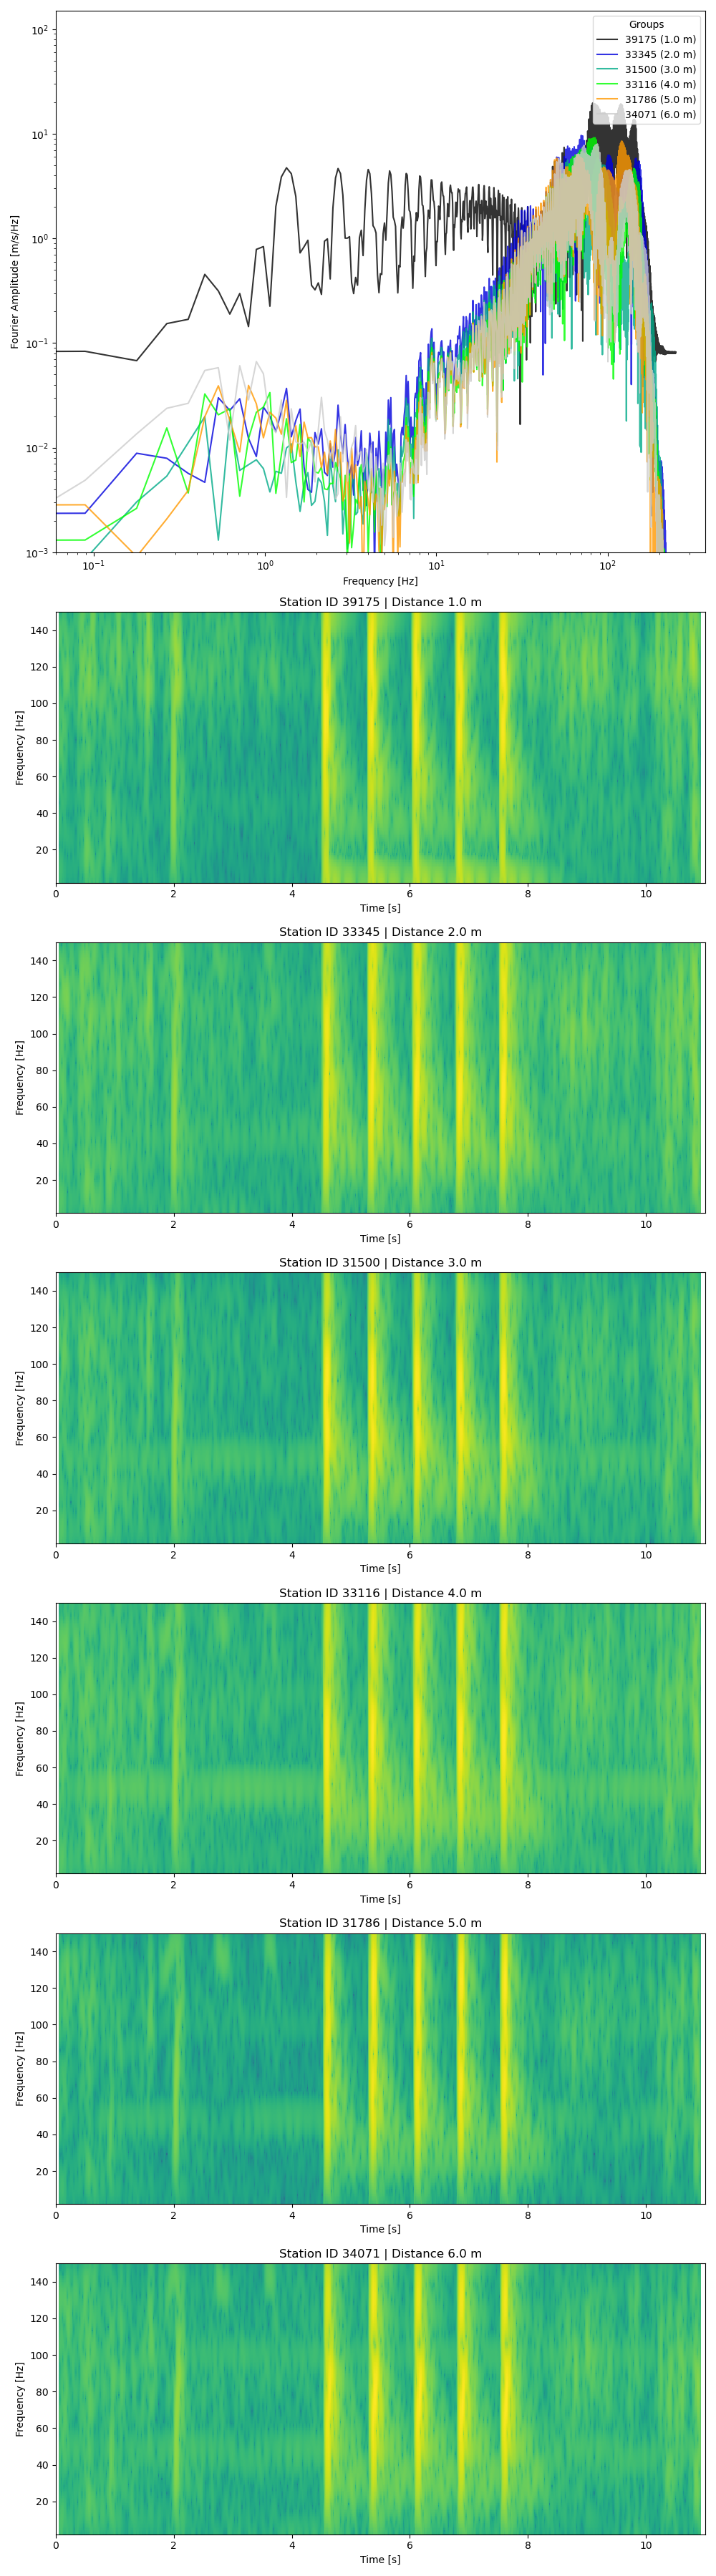

In [100]:
# Ensure 'group' column contains only numeric values and handle NaNs
# df_picks['sta'] = pd.to_numeric(df_picks['sta'], errors='coerce')
# Create a colormap
cmap = ListedColormap(plt.cm.nipy_spectral(np.linspace(0, 1, len(df_picks['sta'].unique()))))
# Ensure 'group' values are within the range of the colormap
num_colors = cmap.N
# Create a color array based on the 'group' column
colors = [cmap(i) for i in range(0, len(df_picks['sta'].unique()))]

# Dictionary to store legend handles
legend_handles = {}

# Create a GridSpec layout
fig = plt.figure(figsize=(10, 6 * len(df_picks['sta'].unique())))
gs = GridSpec(len(df_picks['sta'].unique()) + 1, 1, height_ratios=[2] + [1] * len(df_picks['sta'].unique()))

# First subplot (logarithmic x-axis)
ax0 = fig.add_subplot(gs[0])

# for idx, (ax, station) in enumerate(zip(axes, df_picks['sta'].unique())):
for idx, station in enumerate(df_picks['sta'].unique()):

    selected_sta = df_picks[df_picks['sta'] == station].sort_values('datetime')

    st = read(glob.glob(os.path.join(path_to_strikewise_folder, f"HS{number_hammer_strike:02d}_*/*{station}*.mseed"))[0])

    freq, spec = plot_spectrum(st[0])
    # Add multiple graphs to the first panel
    line, = ax0.plot(freq, np.abs(spec), color=colors[idx], alpha=0.8, label=f'{station} ({selected_sta["distance_to_source"].values[0]} m)')
    
    ax0.set_xscale('log')  # Set x-axis to logarithmic scale
    ax0.set_yscale('log')
    ax0.set_ylim(0.001,150)
    ax0.set_xlabel('Frequency [Hz]')
    ax0.set_ylabel('Fourier Amplitude [m/s/Hz]')

    # Add legend handle if not already added
    if station not in legend_handles:
        # legend_handles[station] = selected_sta['distance_to_source'].values[0]
        legend_handles[station] = f'{station} ({selected_sta["distance_to_source"].values[0]} m)'
    
for idx, station in enumerate(df_picks['sta'].unique()):
    ax = fig.add_subplot(gs[idx + 1])
    selected_sta = df_picks[df_picks['sta'] == station].sort_values('datetime')
    st = read(glob.glob(os.path.join(path_to_strikewise_folder, f"HS{number_hammer_strike:02d}_*/*{station}*.mseed"))[0])
    st.filter('bandpass', freqmin=2, freqmax=150)

    st.spectrogram(wlen=0.1, per_lap=0.9, dbscale=True, log=True, axes=ax, show=False, clip=[0.0, 1.0])
    
    ax.set_title(f"Station ID {station} | Distance {selected_sta['distance_to_source'].values[0]} m")
    ax.set_xlabel('Time [s]')
    ax.set_ylabel('Frequency [Hz]')
    ax.set_xscale('linear')
    ax.set_yscale('linear')
    ax.set_ylim(2, 150)
    
# Create legend
ax0.legend([f'{legend_handles[key]}' for key in legend_handles], title='Groups', loc='upper right')

plt.tight_layout()
plt.show()